# Water Quality Analysis (Inferred Locations)

This notebook replicates the water quality analysis from `water_qual_by_no_location.ipynb`, but with two key differences:
1. It uses inferred village names for ponds that had coordinates but no village name in the raw key.
2. it strictly excludes "no-location" ponds (those with neither coordinates nor village names) from the analysis and visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, cos, sin, asin, sqrt

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return 2 * 6371 * asin(sqrt(a))

# Load Datasets
df_wq = pd.read_csv('data/water_quality.csv')
df_loc = pd.read_csv('data/Shared_ 2026 Github ARA Pond IDs Key.csv')

# Clean Location Data
df_loc_clean = df_loc[['public_pond_id', 'region', 'village', 'latitude', 'longitude']].copy()
df_loc_clean['latitude'] = pd.to_numeric(df_loc_clean['latitude'], errors='coerce')
df_loc_clean['longitude'] = pd.to_numeric(df_loc_clean['longitude'], errors='coerce')
df_loc_clean['has_coords'] = df_loc_clean['latitude'].notna() & df_loc_clean['longitude'].notna()
df_loc_clean['has_village'] = df_loc_clean['village'].notna() & df_loc_clean['village'].astype(str).str.strip().ne('')

# Reference ponds (with village and coords)
ref_ponds = df_loc_clean[df_loc_clean['has_coords'] & df_loc_clean['has_village']].copy()

def infer_village(row):
    if row['has_village']:
        return row['village']
    if not row['has_coords']:
        return None
    
    min_dist = float('inf')
    best_village = None
    
    for _, ref in ref_ponds.iterrows():
        d = haversine_km(row['latitude'], row['longitude'], ref['latitude'], ref['longitude'])
        if d < min_dist:
            min_dist = d
            best_village = ref['village']
    return best_village

df_loc_clean['inferred_village'] = df_loc_clean.apply(infer_village, axis=1)
df_loc_clean['location_status'] = df_loc_clean.apply(
    lambda r: 'Has Location' if (r['has_coords'] or r['has_village']) else 'No Location', axis=1
)

# Rename columns in WQ data to standard names
df_wq = df_wq.rename(columns={
    'Date of data collection': 'Date',
    'Time of data collection': 'Time',
    'DO (mg/L)': 'DO',
    'Temp (in °C)': 'Water Temperature'
})

# Merge and Filter
df = df_wq.merge(df_loc_clean[['public_pond_id', 'inferred_village', 'location_status']], 
                 left_on='pond_id', right_on='public_pond_id', how='left')
df = df[df['location_status'] == 'Has Location'].drop(columns=['public_pond_id', 'location_status'])
df['Date'] = pd.to_datetime(df['Date'])

print(f"Total observations with location (known or inferred): {len(df)}")

Total observations with location (known or inferred): 9932


## Analysis 1 — Water Quality Descriptive Statistics

In [2]:
wq_cols = ['DO', 'pH', 'Water Temperature']
for col in wq_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

stats = df[wq_cols].describe().T
stats['median'] = df[wq_cols].median()
display(stats[['count', 'mean', 'std', 'min', '50%', 'median', 'max']])

,count,mean,std,min,50%,median,max
DO,9919.0,6.602883,3.472178,0.00,4.70,4.70,27.10
pH,9918.0,8.198019,0.269489,5.52,8.23,8.23,9.78
Water Temperature,9913.0,29.458449,2.643862,21.40,29.70,29.70,37.90


## Analysis 2 — Water Quality Distributions

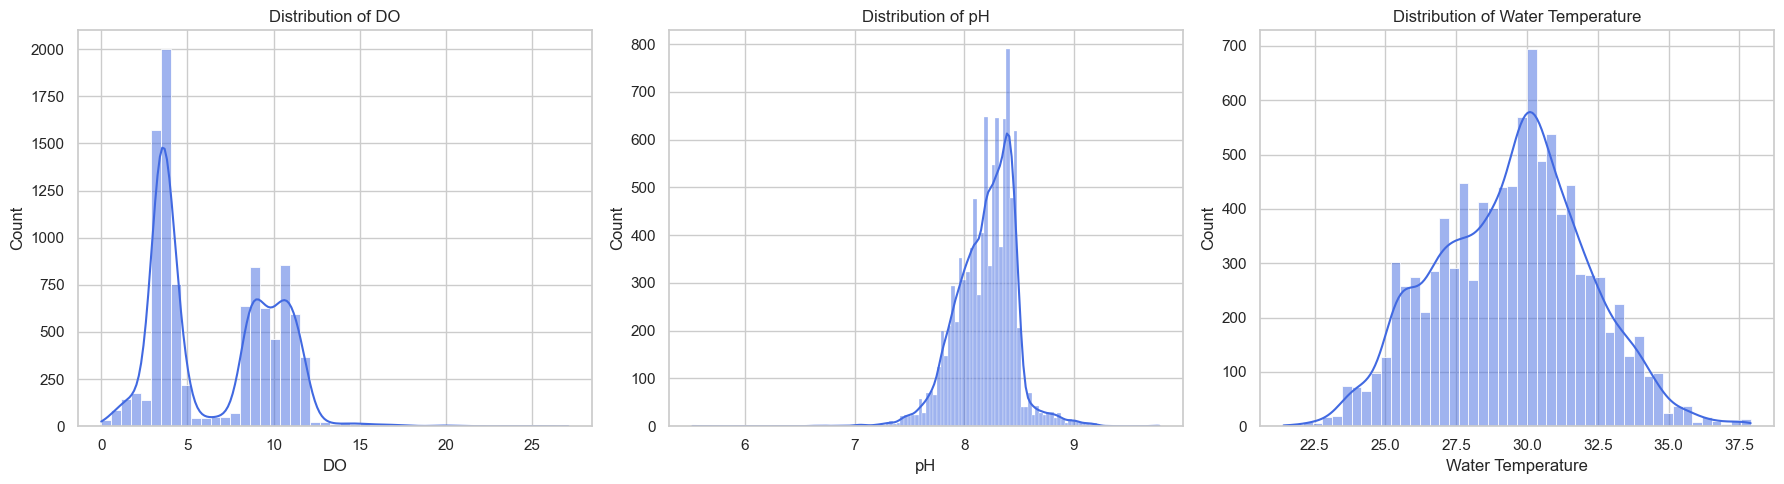

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(wq_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='royalblue')
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

## Analysis 3 — Inter-Measurement Gaps

Distribution and statistics of days between consecutive visits to the same pond.

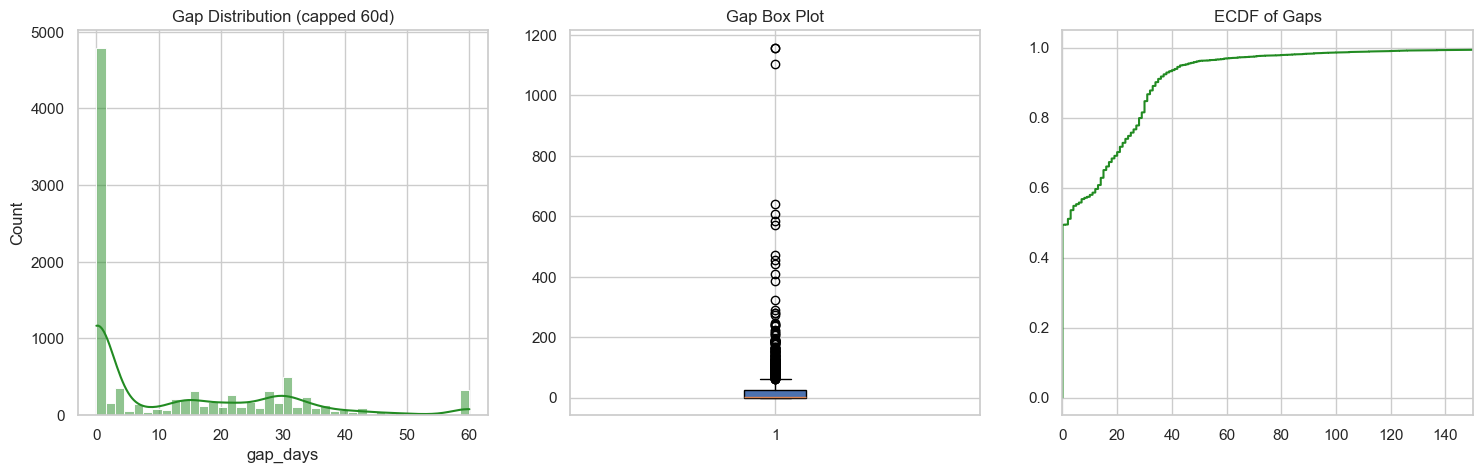

In [4]:
df_sorted = df.sort_values(['pond_id', 'Date'])
df_sorted['prev_date'] = df_sorted.groupby('pond_id')['Date'].shift(1)
df_sorted['gap_days'] = (df_sorted['Date'] - df_sorted['prev_date']).dt.days
gaps = df_sorted.dropna(subset=['gap_days'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cap = 60
data_plot = gaps['gap_days'].clip(upper=cap)
sns.histplot(data_plot, bins=40, kde=True, color='forestgreen', ax=axes[0])
axes[0].set_title(f'Gap Distribution (capped {cap}d)')
axes[1].boxplot(gaps['gap_days'], vert=True, patch_artist=True)
axes[1].set_title('Gap Box Plot')
sorted_g = np.sort(gaps['gap_days'])
ecdf_y = np.arange(1, len(sorted_g) + 1) / len(sorted_g)
axes[2].plot(sorted_g, ecdf_y, color='forestgreen')
axes[2].set_xlim(0, 150)
axes[2].set_title('ECDF of Gaps')
plt.show()

## Analysis 4 — Gap Interval Categories

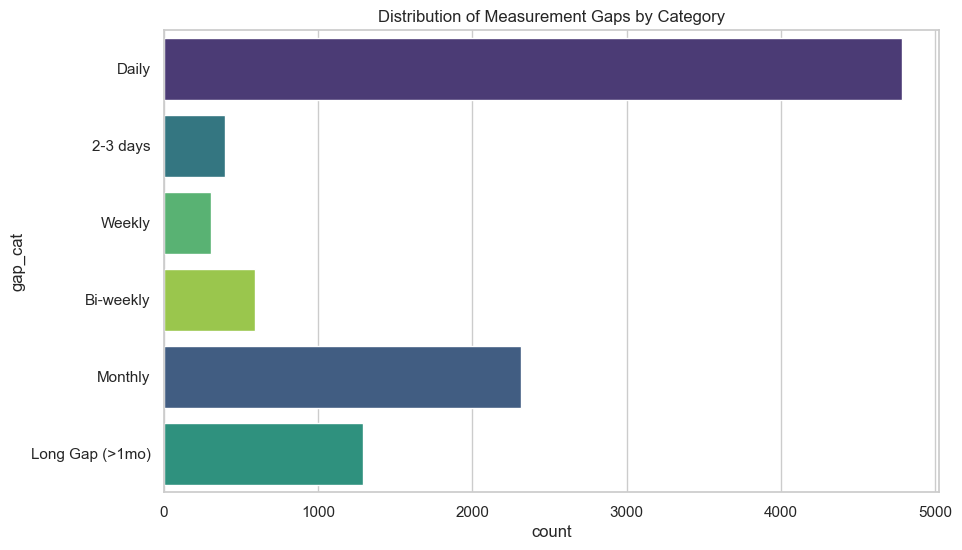

In [5]:
def get_gap_cat(d):
    if d <= 1: return 'Daily'
    if d <= 3: return '2-3 days'
    if d <= 7: return 'Weekly'
    if d <= 14: return 'Bi-weekly'
    if d <= 31: return 'Monthly'
    return 'Long Gap (>1mo)'

gaps = gaps.copy()
gaps['gap_cat'] = gaps['gap_days'].apply(get_gap_cat)
cat_order = ['Daily', '2-3 days', 'Weekly', 'Bi-weekly', 'Monthly', 'Long Gap (>1mo)']

plt.figure(figsize=(10, 6))
sns.countplot(y='gap_cat', data=gaps, order=cat_order, palette='viridis', hue='gap_cat', legend=False)
plt.title('Distribution of Measurement Gaps by Category')
plt.show()

## Analysis 5 — Per-Pond Observation Counts

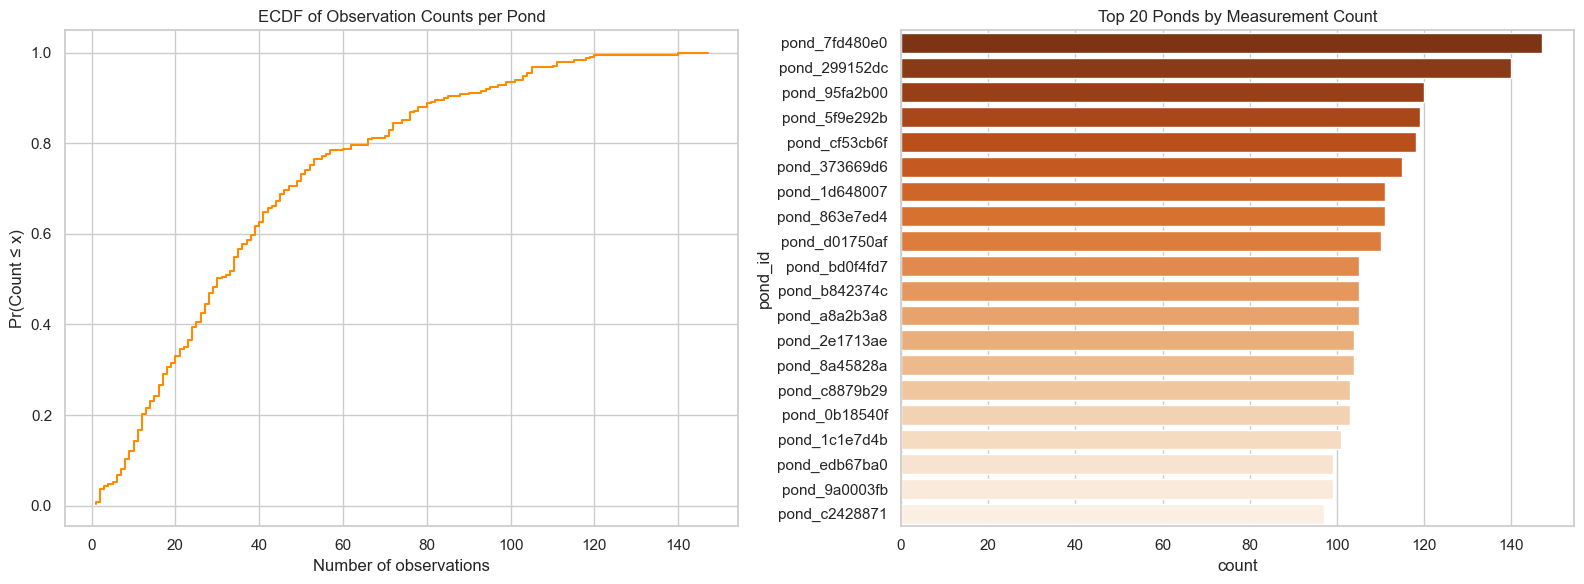

In [6]:
pond_counts = df['pond_id'].value_counts().reset_index()
pond_counts.columns = ['pond_id', 'count']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sorted_counts = np.sort(pond_counts['count'])
yvals = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts)
axes[0].step(sorted_counts, yvals, color='darkorange')
axes[0].set_title('ECDF of Observation Counts per Pond')
axes[0].set_xlabel('Number of observations')
axes[0].set_ylabel('Pr(Count ≤ x)')

sns.barplot(x='count', y='pond_id', data=pond_counts.head(20), ax=axes[1], palette='Oranges_r', hue='pond_id', legend=False)
axes[1].set_title('Top 20 Ponds by Measurement Count')
plt.tight_layout()
plt.show()

## Analysis 6 — Measurement Frequency (Daily & Monthly)

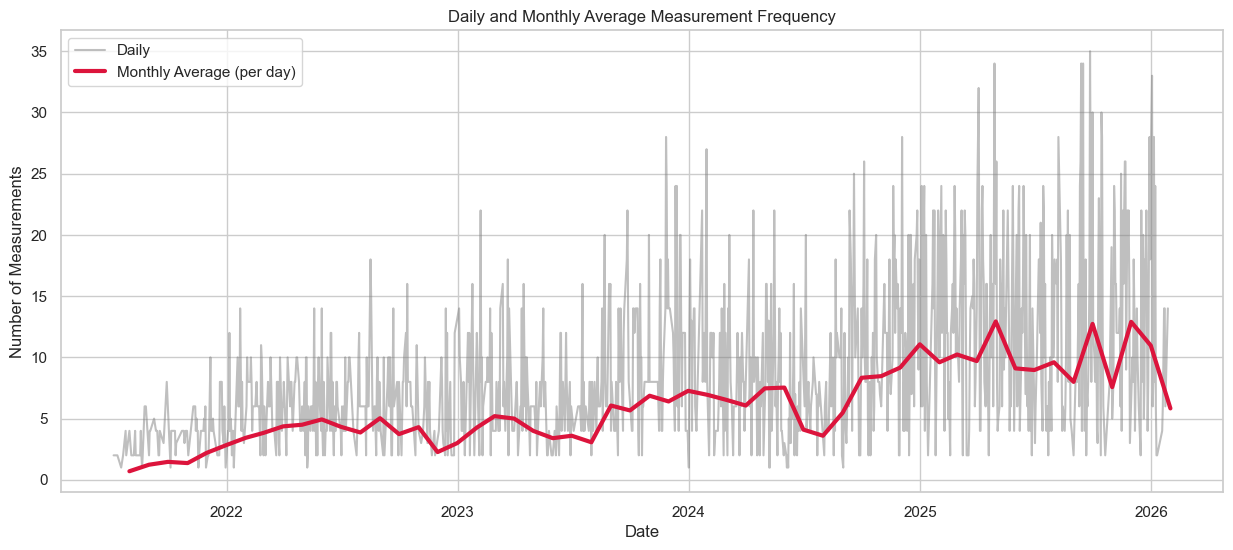

In [7]:
daily_counts = df.groupby('Date').size()
monthly_counts = df.set_index('Date').resample('ME').size()

plt.figure(figsize=(15, 6))
plt.plot(daily_counts.index, daily_counts.values, label='Daily', alpha=0.5, color='gray')
plt.plot(monthly_counts.index, monthly_counts.values / 30, label='Monthly Average (per day)', linewidth=3, color='crimson')
plt.title('Daily and Monthly Average Measurement Frequency')
plt.xlabel('Date')
plt.ylabel('Number of Measurements')
plt.legend()
plt.show()

## Analysis 7 — Day of Week and Day of Year Analysis

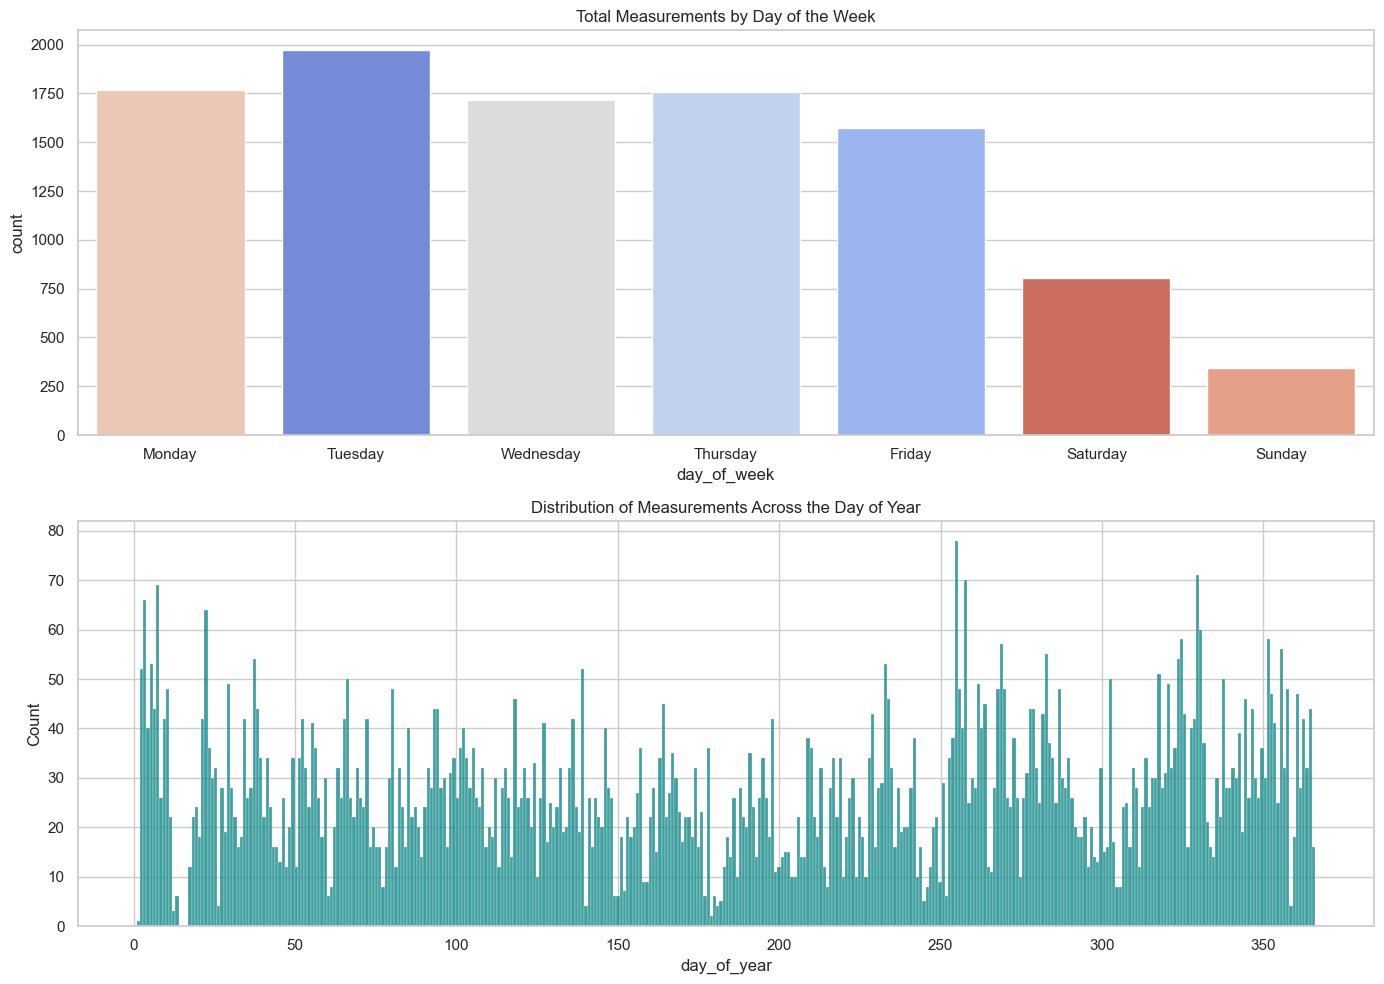

In [8]:
df['day_of_week'] = df['Date'].dt.day_name()
df['day_of_year'] = df['Date'].dt.dayofyear
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
sns.countplot(x='day_of_week', data=df, order=days_order, palette='coolwarm', ax=axes[0], hue='day_of_week', legend=False)
axes[0].set_title('Total Measurements by Day of the Week')
sns.histplot(df['day_of_year'], bins=366, color='teal', ax=axes[1])
axes[1].set_title('Distribution of Measurements Across the Day of Year')
plt.tight_layout()
plt.show()

## Analysis 8 — Water Quality Trends Over Time

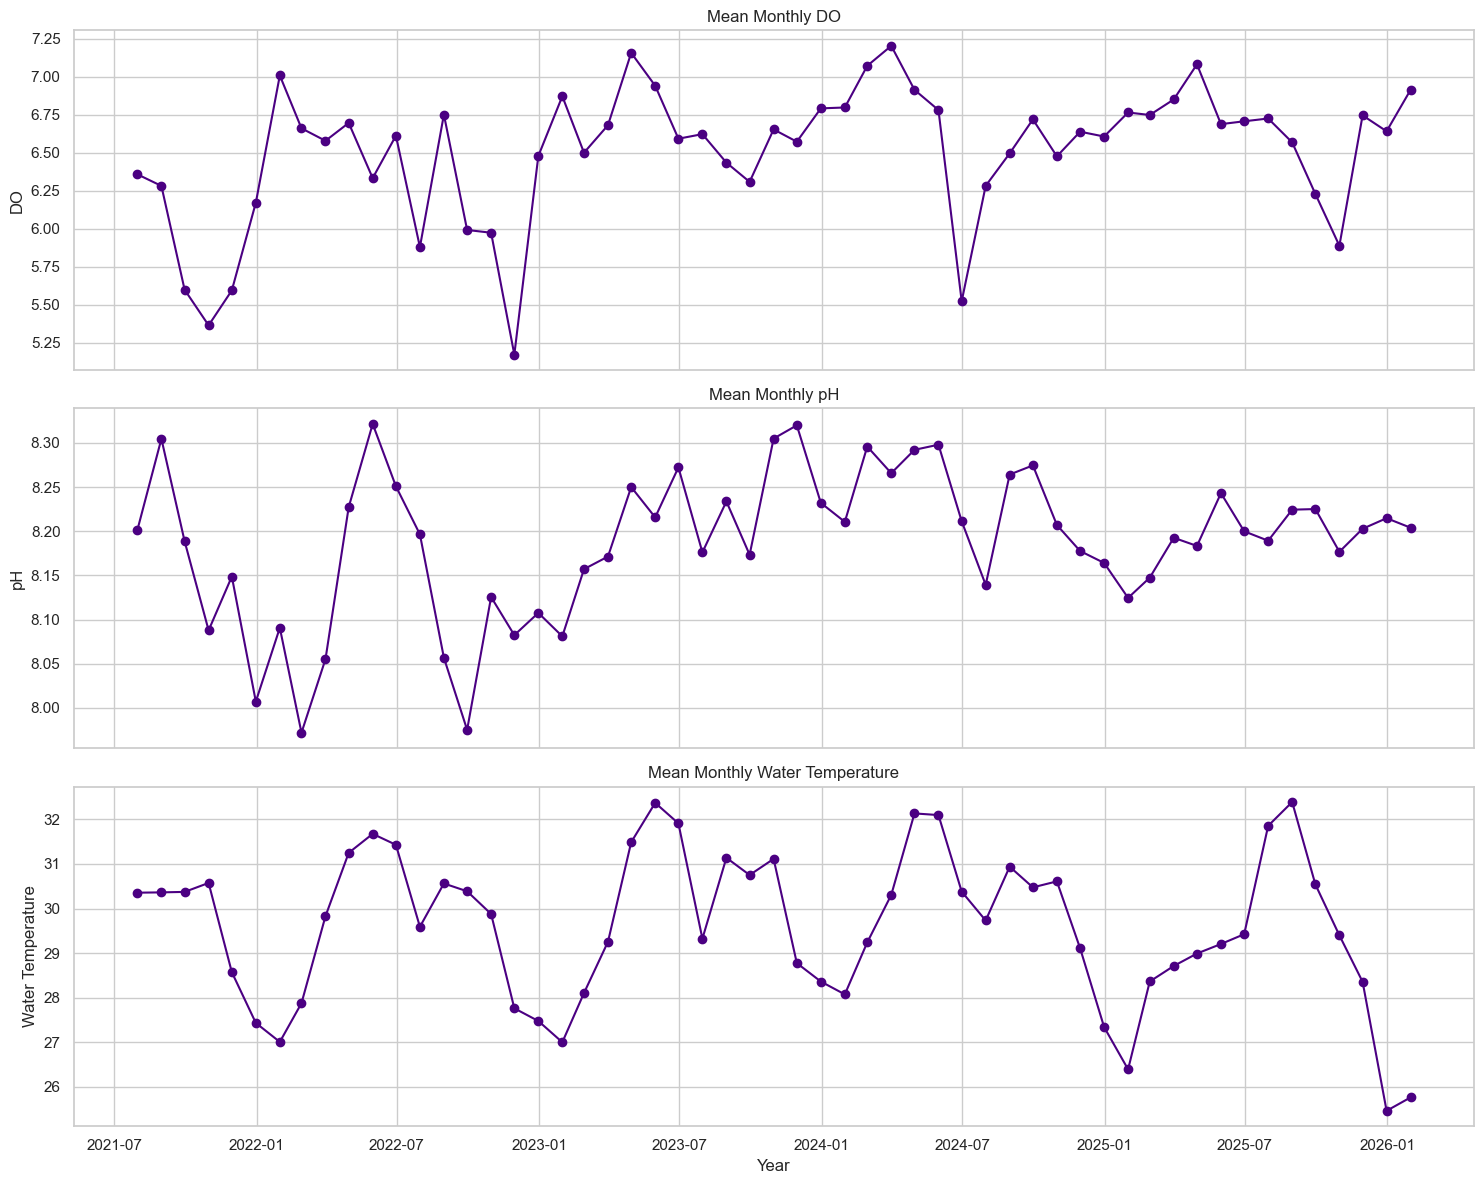

In [9]:
monthly_means = df.set_index('Date').resample('ME')[wq_cols].mean()

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
for i, col in enumerate(wq_cols):
    axes[i].plot(monthly_means.index, monthly_means[col], marker='o', linestyle='-', color='indigo')
    axes[i].set_ylabel(col)
    axes[i].set_title(f'Mean Monthly {col}')
plt.xlabel('Year')
plt.tight_layout()
plt.show()

## Analysis 9 — Monthly Boxplots

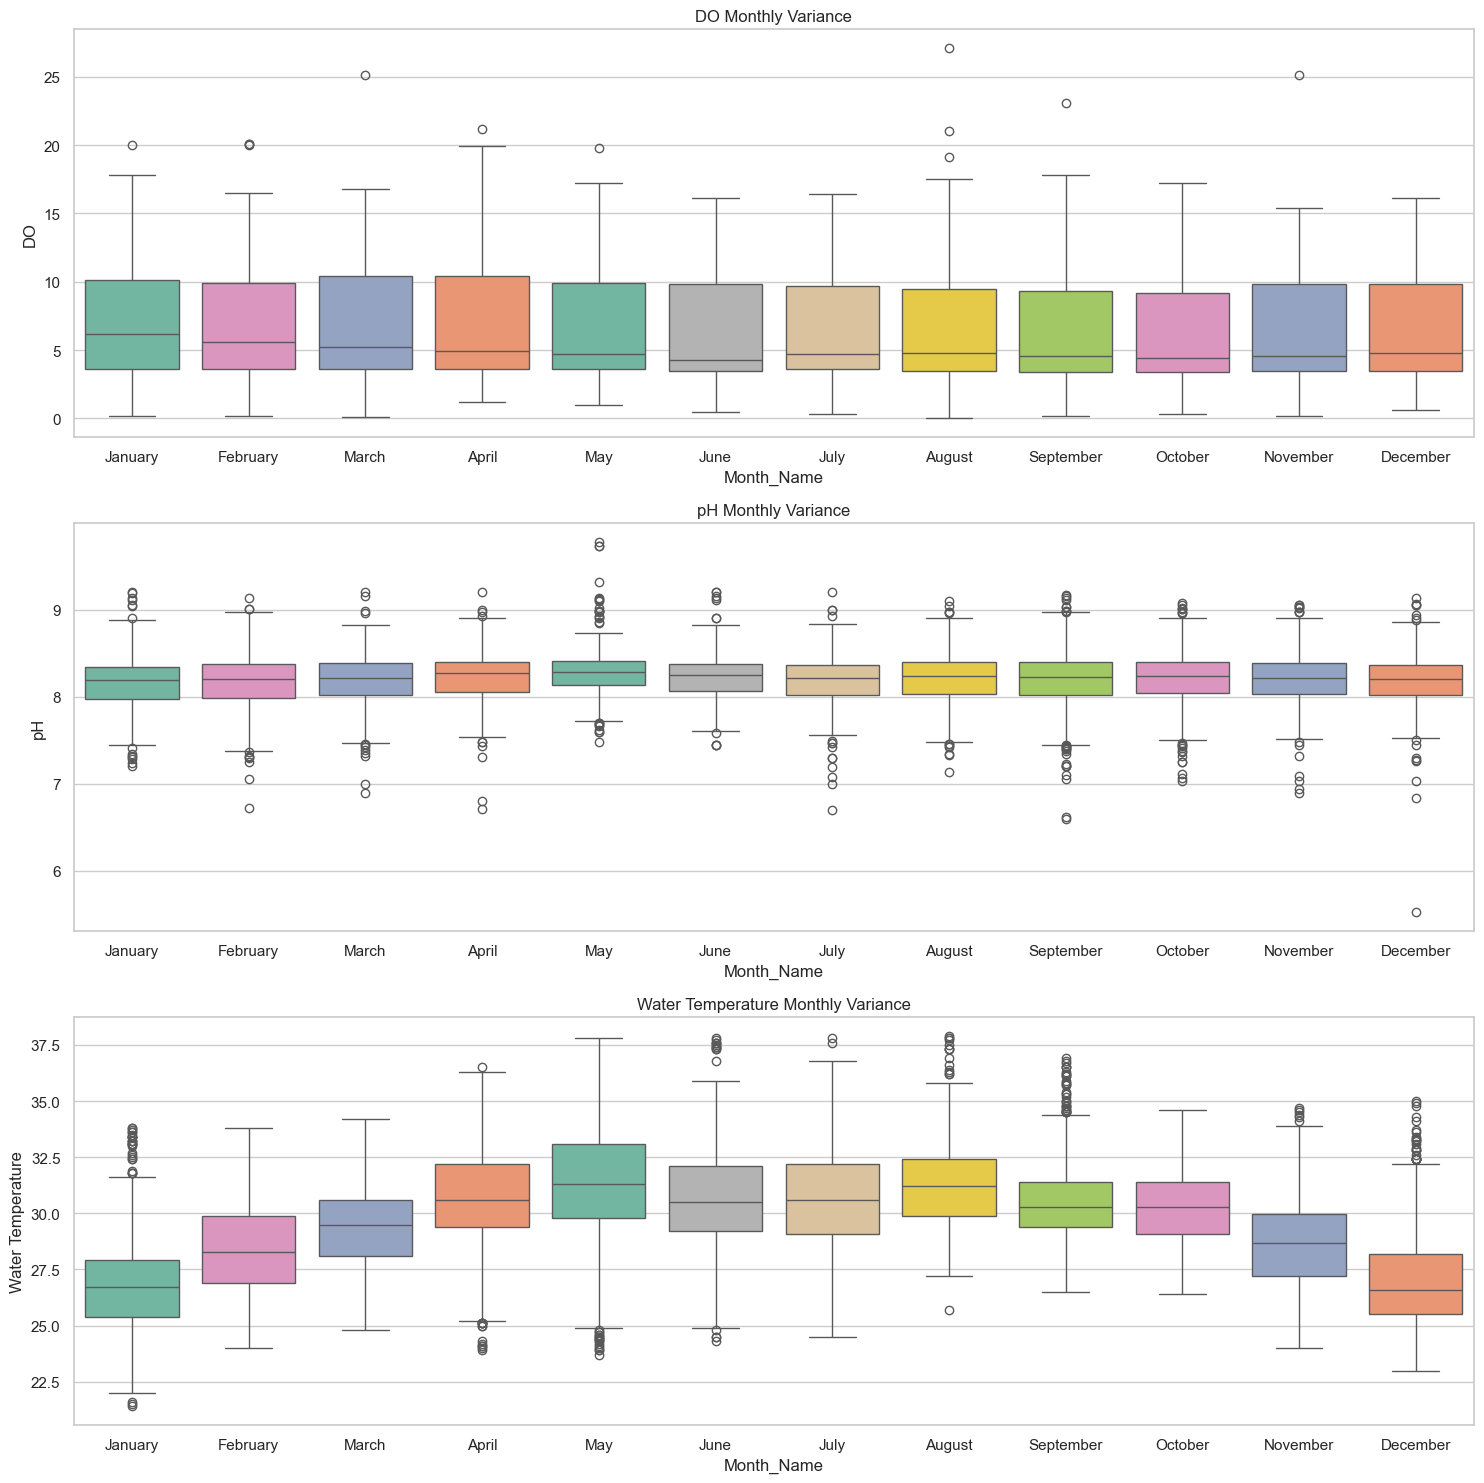

In [10]:
df['Month_Name'] = df['Date'].dt.month_name()
months_subset = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

fig, axes = plt.subplots(3, 1, figsize=(15, 15))
for i, col in enumerate(wq_cols):
    sns.boxplot(x='Month_Name', y=col, data=df, order=months_subset, ax=axes[i], palette='Set2', hue='Month_Name', legend=False)
    axes[i].set_title(f'{col} Monthly Variance')
plt.tight_layout()
plt.show()

## Analysis 10 — Seasonal Analysis

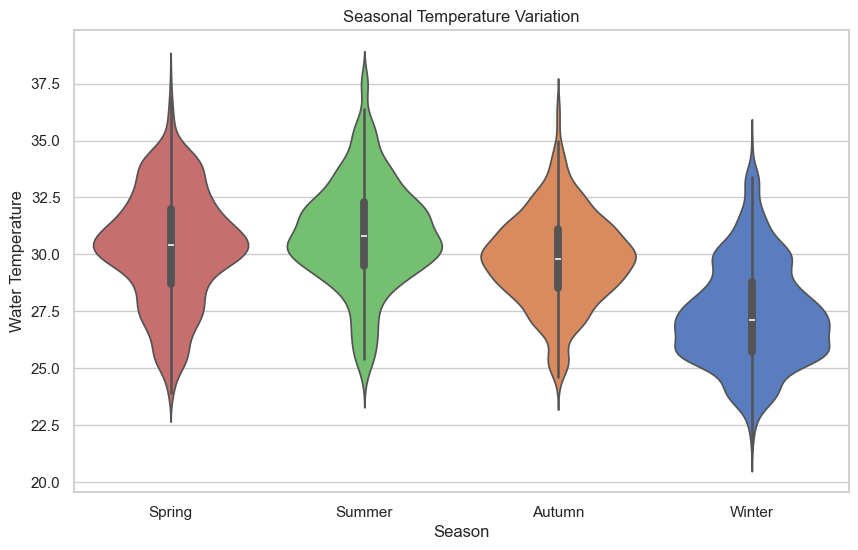

In [11]:
def get_season(month):
    if month in [3, 4, 5]: return 'Spring'
    if month in [6, 7, 8]: return 'Summer'
    if month in [9, 10, 11]: return 'Autumn'
    return 'Winter'

df['Season'] = df['Date'].dt.month.apply(get_season)
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']

plt.figure(figsize=(10, 6))
sns.violinplot(x='Season', y='Water Temperature', data=df, order=season_order, palette='muted', hue='Season', legend=False)
plt.title('Seasonal Temperature Variation')
plt.show()

## Analysis 11 — Dissolved Oxygen by Time (Morning Phase)

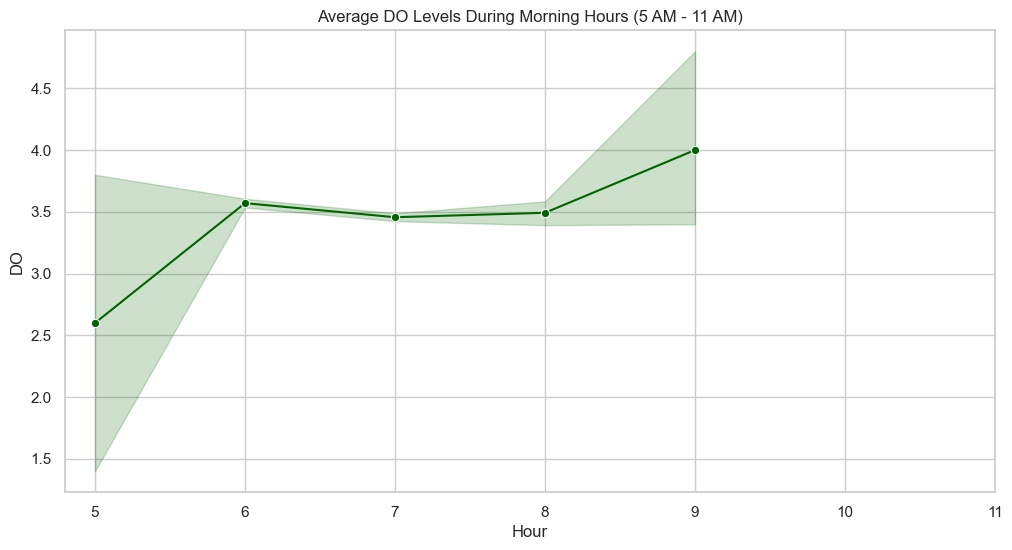

In [12]:
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M', errors='coerce').dt.hour
morning_df = df[df['Hour'].between(5, 11)]

if not morning_df.empty:
    plt.figure(figsize=(12, 6))
    sns.lineplot(x='Hour', y='DO', data=morning_df, marker='o', color='darkgreen')
    plt.title('Average DO Levels During Morning Hours (5 AM - 11 AM)')
    plt.xticks(range(5, 12))
    plt.show()
else:
    print("No morning data available for DO analysis.")

## Analysis 12 — Correlation Heatmap

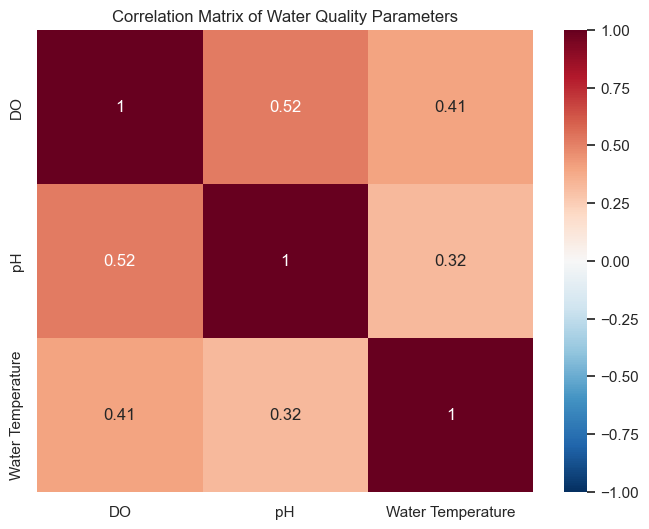

In [13]:
corr = df[wq_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='RdBu_r', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Water Quality Parameters')
plt.show()

## Analysis 13 — Parameter Inter-relationships

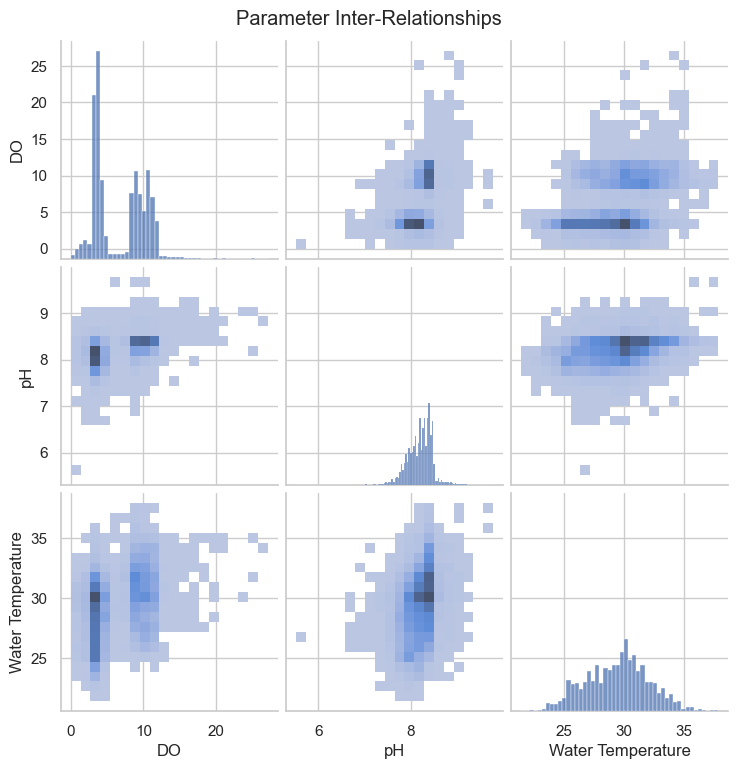

In [14]:
sns.pairplot(df[wq_cols].dropna(), kind='hist', plot_kws={'bins':20})
plt.suptitle('Parameter Inter-Relationships', y=1.02)
plt.show()

## Analysis 14 — Regional Statistics

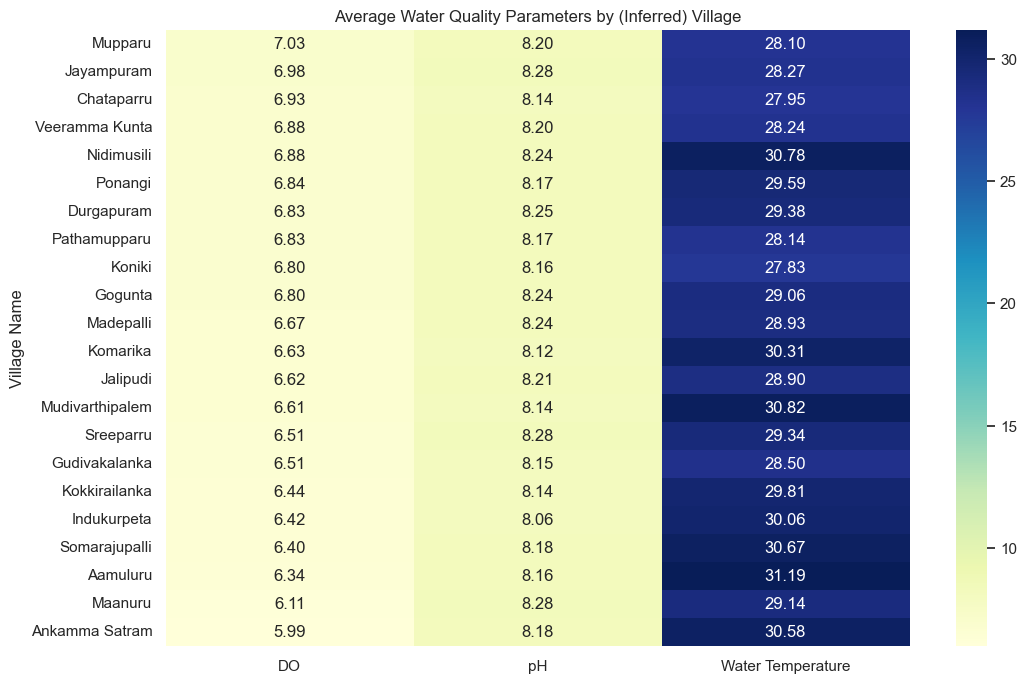

In [15]:
village_stats = df.groupby('inferred_village')[wq_cols].mean().sort_values('DO', ascending=False)
plt.figure(figsize=(12, 8))
sns.heatmap(village_stats, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title('Average Water Quality Parameters by (Inferred) Village')
plt.ylabel('Village Name')
plt.show()

## Analysis 15 — Summary and Outlier Check

In [16]:
for col in wq_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = df[(df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)]
    print(f"{col} - Total Outliers Detected: {len(outliers)}")

DO - Total Outliers Detected: 13
pH - Total Outliers Detected: 185
Water Temperature - Total Outliers Detected: 36
